In [1]:
!wget https://thor.robots.ox.ac.uk/datasets/pets/images.tar.gz

--2026-06-12 11:47:22--  https://thor.robots.ox.ac.uk/datasets/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 308 Permanent Redirect
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2026-06-12 11:47:24--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Reusing existing connection to thor.robots.ox.ac.uk:443.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘images.tar.gz’

images.tar.gz       100%[===================>] 755.23M  14.4MB/s    in 56s     

2026-06-12 11:48:20 (13.5 MB/s) - ‘images.tar.gz’ saved [791918971/791918971]



In [2]:
!wget https://thor.robots.ox.ac.uk/datasets/pets/annotations.tar.gz

--2026-06-12 11:48:20--  https://thor.robots.ox.ac.uk/datasets/pets/annotations.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 308 Permanent Redirect
Location: https://thor.robots.ox.ac.uk/pets/annotations.tar.gz [following]
--2026-06-12 11:48:22--  https://thor.robots.ox.ac.uk/pets/annotations.tar.gz
Reusing existing connection to thor.robots.ox.ac.uk:443.
HTTP request sent, awaiting response... 200 OK
Length: 19173078 (18M) [application/octet-stream]
Saving to: ‘annotations.tar.gz’

annotations.tar.gz  100%[===================>]  18.28M  4.40MB/s    in 4.2s    

2026-06-12 11:48:27 (4.40 MB/s) - ‘annotations.tar.gz’ saved [19173078/19173078]



In [3]:
!tar -xf images.tar.gz
!tar -xf annotations.tar.gz

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
import random
from torchvision import transforms
import torchvision.transforms.functional as TF
from torch.utils.data import DataLoader, random_split


In [5]:
class SegDataset(Dataset):
    def __init__(self, image_dir, mask_dir, img_size=128, mask_size=88, augment=False):
        super().__init__()
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        self.mask_size = mask_size
        self.augment = augment
        self.images = [f for f in os.listdir(self.image_dir) if f.endswith('.jpg')]

        self.img_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])

        self.mask_resize = transforms.Resize(
            (mask_size, mask_size),
            interpolation=transforms.InterpolationMode.NEAREST
        )

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        mask_name = img_name.replace('.jpg', '.png')

        img_path  = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, mask_name)

        image = Image.open(img_path).convert('RGB')
        mask  = Image.open(mask_path)

        # Paired augmentation before resizing
        if self.augment:
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask  = TF.hflip(mask)
            if random.random() > 0.5:
                angle = random.uniform(-15, 15)
                image = TF.rotate(image, angle)
                mask  = TF.rotate(mask,  angle,
                                  interpolation=TF.InterpolationMode.NEAREST)
            if random.random() > 0.5:
                image = TF.adjust_brightness(image, random.uniform(0.8, 1.2))
                image = TF.adjust_contrast(image,   random.uniform(0.8, 1.2))

        image = self.img_transform(image)
        mask  = self.mask_resize(mask)

        mask = torch.as_tensor(
            torch.ByteTensor(torch.ByteStorage.from_buffer(mask.tobytes())),
            dtype=torch.long
        )
        mask = mask.view(self.mask_size, self.mask_size)
        mask = mask - 1  # trimap values 1,2,3 → 0,1,2
        # clamp so any stray 0-valued pixels don't become -1 and corrupt the loss
        mask = mask.clamp(0, 2)

        return image, mask


In [6]:
class Conv3X3(nn.Module):
    def __init__(self, input_channels, output_channels):
        super().__init__()
        # No padding — faithful to the original U-Net paper (valid convolutions)
        self.conv1 = nn.Conv2d(input_channels,  output_channels, kernel_size=3, padding=0)
        self.conv2 = nn.Conv2d(output_channels, output_channels, kernel_size=3, padding=0)
        self.relu  = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.conv2(self.relu(self.conv1(x))))


class MaxPooling(nn.Module):
    def __init__(self):
        super().__init__()
        self.mx_pool = nn.MaxPool2d(kernel_size=2)

    def forward(self, x):
        return self.mx_pool(x)


class UpSampling(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up_conv = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

    def forward(self, x):
        return self.up_conv(x)


class Unet(nn.Module):
    def __init__(self, in_channels=3, inter_channels=64, out_channels=3):
        super().__init__()
        self.conv3x3_1 = Conv3X3(in_channels,      inter_channels)
        self.mx_pool_1 = MaxPooling()
        self.conv3x3_2 = Conv3X3(inter_channels,    2 * inter_channels)
        self.mx_pool_2 = MaxPooling()
        self.conv3x3_3 = Conv3X3(2 * inter_channels, 4 * inter_channels)  # bottleneck

        self.dropout = nn.Dropout2d(p=0.3)

        self.up_sampling_1 = UpSampling(4 * inter_channels, 2 * inter_channels)
        self.conv3x3_4     = Conv3X3(4 * inter_channels, 2 * inter_channels)
        self.up_sampling_2 = UpSampling(2 * inter_channels, inter_channels)
        self.conv3x3_5     = Conv3X3(2 * inter_channels, inter_channels)

        self.conv1x1 = nn.Conv2d(inter_channels, out_channels, kernel_size=1)

    def forward(self, x):
        cache_1 = self.conv3x3_1(x)          # encoder level 1
        down_1  = self.mx_pool_1(cache_1)

        cache_2 = self.conv3x3_2(down_1)     # encoder level 2
        down_2  = self.mx_pool_2(cache_2)

        y1 = self.conv3x3_3(down_2)          # bottleneck
        y1 = self.dropout(y1)

        up_1 = self.up_sampling_1(y1)
        cache_2_cropped = TF.center_crop(cache_2, [up_1.shape[2], up_1.shape[3]])
        y2 = self.conv3x3_4(torch.cat((cache_2_cropped, up_1), dim=1))

        up_2 = self.up_sampling_2(y2)
        cache_1_cropped = TF.center_crop(cache_1, [up_2.shape[2], up_2.shape[3]])
        y3 = self.conv3x3_5(torch.cat((cache_1_cropped, up_2), dim=1))
        y3 = self.dropout(y3)

        return self.conv1x1(y3)


In [7]:
dataset_size = len(SegDataset('/content/images', '/content/annotations/trimaps'))
train_size = int(0.8 * dataset_size)
test_size  = dataset_size - train_size

# Use a fixed split so train/test don't overlap
indices = torch.randperm(dataset_size).tolist()
train_idx, test_idx = indices[:train_size], indices[train_size:]

from torch.utils.data import Subset
train_dataset = Subset(
    SegDataset('/content/images', '/content/annotations/trimaps', augment=True),
    train_idx
)
test_dataset = Subset(
    SegDataset('/content/images', '/content/annotations/trimaps', augment=False),
    test_idx
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False,
                          num_workers=2, pin_memory=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Training on: {device}')

model     = Unet(in_channels=3, inter_channels=64, out_channels=3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-6)

epochs = 25

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), masks)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    scheduler.step()
    avg_train_loss = running_train_loss / len(train_loader)

    model.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        for images, masks in test_loader:
            images, masks = images.to(device), masks.to(device)
            running_test_loss += criterion(model(images), masks).item()

    avg_test_loss = running_test_loss / len(test_loader)
    print(f'Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f} | '
          f'Test Loss: {avg_test_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}')


Training on: cuda


/tmp/ipykernel_4763/3190468375.py:37: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  mask = torch.as_tensor(torch.ByteTensor(torch.ByteStorage.from_buffer(mask.tobytes())), dtype=torch.long)


Epoch [1/10] | Train Loss: 0.9203 | Test Loss: 0.8775
Epoch [2/10] | Train Loss: 0.8727 | Test Loss: 0.8642
Epoch [3/10] | Train Loss: 0.8615 | Test Loss: 0.8556
Epoch [4/10] | Train Loss: 0.8469 | Test Loss: 0.8418
Epoch [5/10] | Train Loss: 0.8183 | Test Loss: 0.8488
Epoch [6/10] | Train Loss: 0.7659 | Test Loss: 0.7394
Epoch [7/10] | Train Loss: 0.7315 | Test Loss: 0.7240
Epoch [8/10] | Train Loss: 0.7131 | Test Loss: 0.7007
Epoch [9/10] | Train Loss: 0.6969 | Test Loss: 0.6946
Epoch [10/10] | Train Loss: 0.6839 | Test Loss: 0.6688


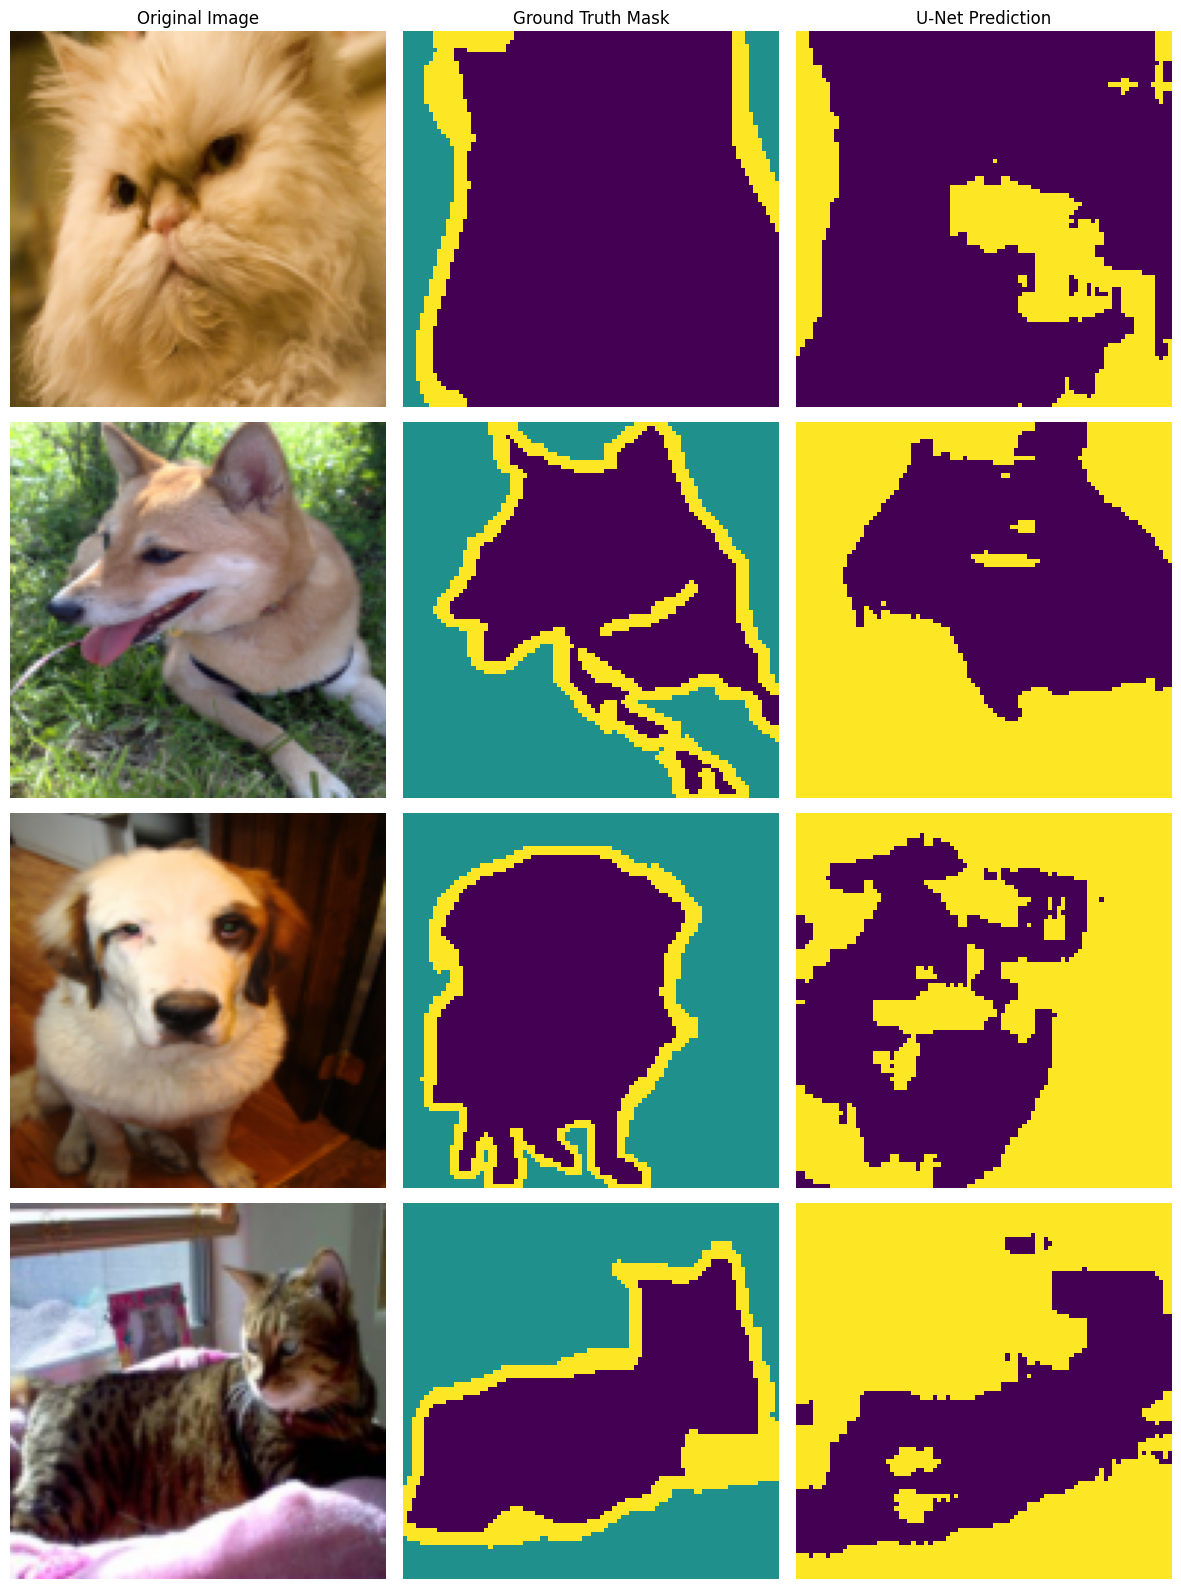

In [8]:
import matplotlib.pyplot as plt

model.eval()
images, masks = next(iter(test_loader))
images, masks = images.to(device), masks.to(device)

with torch.no_grad():
    predicted_masks = torch.argmax(model(images), dim=1)

images, masks, predicted_masks = images.cpu(), masks.cpu(), predicted_masks.cpu()

# Un-normalize for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

num_images_to_show = 4
fig, axes = plt.subplots(num_images_to_show, 3, figsize=(12, 4 * num_images_to_show))

for i in range(num_images_to_show):
    img_np = (images[i] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title('Original Image' if i == 0 else '')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(masks[i].numpy(), cmap='viridis')
    axes[i, 1].set_title('Ground Truth Mask' if i == 0 else '')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(predicted_masks[i].numpy(), cmap='viridis')
    axes[i, 2].set_title('U-Net Prediction' if i == 0 else '')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()
